<a href="https://colab.research.google.com/github/xtina999/python-ecommerce-analysis/blob/main/notebook/Exploratory_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Data overview. Розуміння даних та їх змісту.

Наш датасет містить три пов'язані таблиці - products, countries, events.

*   Product включає в себе:

    - id продукту
    - назву продутку
*   Countries - опис країни. Таблиця включає в себе

    - назву країни
    - скорочення з двох символів
    - назву регіону
    - назву суб-регіону

*   Events - події повязані з продажем продукції компанії.
Таблиця включає:

    - id замовлення
    - дату замовлення
    - дата відправки товару
    - пріоритет замовлення, а саме C — Critical (критичний), H — High (високий пріоритет), M — Medium (середній), L — Low (низький)
    - код країни з трьох символів
    - id продукту
    - канал продажу(офлайн чи онлайн)
    - к-сть проданих одиниць
    - ціна одиниці(ціна продажу)
    - вартість одиниці(вартість по якій закуплена)

Ключові стовпці в таблицях наступні:

     - products: id
     - countries: alpha_3
     - events: order_id
Таблиці звязані, звязок в таблиці events де є Country Code та Product ID



In [ ]:
# all imports
from google.colab import drive

import pandas as pd
import numpy as np
import unicodedata

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Connecting Google Drive
drive.mount("/content/drive")
%cd /content/drive/MyDrive/ColabNotebooks/code/FinalProject


# Import CSV file
products = pd.read_csv("products.csv")
countries = pd.read_csv("countries.csv")
events = pd.read_csv("events.csv")

products.head()

Mounted at /content/drive
/content/drive/MyDrive/ColabNotebooks/code/FinalProject


,id,item_type
0,2103,Cereal
1,7940,Household
2,2455,Clothes
3,1270,Beverages
4,8681,Office Supplies


In [ ]:
countries.head()

,name,alpha-2,alpha-3,region,sub-region
0,Afghanistan,AF,AFG,Asia,Southern Asia
1,Åland Islands,AX,ALA,Europe,Northern Europe
2,Albania,AL,ALB,Europe,Southern Europe
3,Algeria,DZ,DZA,Africa,Northern Africa
4,American Samoa,AS,ASM,Oceania,Polynesia


In [ ]:
events.head()

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
0,100640618,10/8/2014,10/18/2014,M,NOR,2103,Online,650.0,205.70,117.11
1,100983083,8/11/2016,8/11/2016,C,SRB,2103,Offline,1993.0,205.70,117.11
2,101025998,7/18/2014,8/11/2014,M,NaN,7940,Online,4693.0,668.27,502.54
3,102230632,5/13/2017,6/13/2017,L,MNE,2455,Online,1171.0,109.28,35.84
4,103435266,8/11/2012,9/18/2012,H,SRB,1270,Offline,7648.0,47.45,31.79


## 2. Data cleaning. Робота таблицями, із пропущеними даними, некоректними даними, аномаліями.

In [ ]:
# Converting tables to DataFrames
df_products = pd.DataFrame(products)
df_countries = pd.DataFrame(countries)
df_events = pd.DataFrame(events)

print(df_products.head())
print(df_countries.head())
print(df_events.head())

     id        item_type
0  2103           Cereal
1  7940        Household
2  2455          Clothes
3  1270        Beverages
4  8681  Office Supplies
             name alpha-2 alpha-3   region       sub-region
0     Afghanistan      AF     AFG     Asia    Southern Asia
1   Åland Islands      AX     ALA   Europe  Northern Europe
2         Albania      AL     ALB   Europe  Southern Europe
3         Algeria      DZ     DZA   Africa  Northern Africa
4  American Samoa      AS     ASM  Oceania        Polynesia
    Order ID Order Date   Ship Date Order Priority Country Code  Product ID  \
0  100640618  10/8/2014  10/18/2014              M          NOR        2103   
1  100983083  8/11/2016   8/11/2016              C          SRB        2103   
2  101025998  7/18/2014   8/11/2014              M          NaN        7940   
3  102230632  5/13/2017   6/13/2017              L          MNE        2455   
4  103435266  8/11/2012   9/18/2012              H          SRB        1270   

  Sales Channel

In [ ]:
# Change column names to snake_case format
df_events.columns = df_events.columns.str.lower().str.replace(' ', '_')
df_countries.columns = df_countries.columns = (
    df_countries.columns
        .str.strip()
        .str.lower()
        .str.replace(r'[ -]+', '_', regex=True)
)
print(df_events.head())
print(df_countries.head())

    order_id order_date   ship_date order_priority country_code  product_id  \
0  100640618  10/8/2014  10/18/2014              M          NOR        2103   
1  100983083  8/11/2016   8/11/2016              C          SRB        2103   
2  101025998  7/18/2014   8/11/2014              M          NaN        7940   
3  102230632  5/13/2017   6/13/2017              L          MNE        2455   
4  103435266  8/11/2012   9/18/2012              H          SRB        1270   

  sales_channel  units_sold  unit_price  unit_cost  
0        Online       650.0      205.70     117.11  
1       Offline      1993.0      205.70     117.11  
2        Online      4693.0      668.27     502.54  
3        Online      1171.0      109.28      35.84  
4       Offline      7648.0       47.45      31.79  
             name alpha_2 alpha_3   region       sub_region
0     Afghanistan      AF     AFG     Asia    Southern Asia
1   Åland Islands      AX     ALA   Europe  Northern Europe
2         Albania      AL  

In [ ]:
# Checking the number of rows and columns in a table
print(df_products.shape)
print(df_countries.shape)
print(df_events.shape)

(12, 2)
(249, 5)
(1330, 10)


### Виявлення пропущених значень та робота над ними

In [ ]:
print("products")
print(df_products.isna().sum())
print("countries")
print(df_countries.isna().sum())
print("events")
print(df_events.isna().sum())
print("-----------------------------------------------------------------")
print("products")
print(df_products.isna().sum() / df_products.shape[0] * 100)
print("countries")
print(df_countries.isna().sum() / df_countries.shape[0] * 100)
print("events")
print(df_events.isna().sum() / df_events.shape[0] * 100)


products
id           0
item_type    0
dtype: int64
countries
name          0
alpha_2       1
alpha_3       0
region        1
sub_region    1
dtype: int64
events
order_id           0
order_date         0
ship_date          0
order_priority     0
country_code      82
product_id         0
sales_channel      0
units_sold         2
unit_price         0
unit_cost          0
dtype: int64
-----------------------------------------------------------------
products
id           0.0
item_type    0.0
dtype: float64
countries
name          0.000000
alpha_2       0.401606
alpha_3       0.000000
region        0.401606
sub_region    0.401606
dtype: float64
events
order_id          0.000000
order_date        0.000000
ship_date         0.000000
order_priority    0.000000
country_code      6.165414
product_id        0.000000
sales_channel     0.000000
units_sold        0.150376
unit_price        0.000000
unit_cost         0.000000
dtype: float64


In [ ]:
# Processing missing values in countries
df_countries[df_countries.isna().any(axis=1)]
df_countries.loc[df_countries['name'] == 'Namibia', 'alpha_2'] = 'NA'
df_countries.loc[df_countries['name'] == 'Antarctica', 'region'] = 'Non-available'
df_countries.loc[df_countries['name'] == 'Antarctica', 'sub_region'] = 'Non-available'
df_countries[df_countries.isna().any(axis=1)]

,name,alpha_2,alpha_3,region,sub_region


In [ ]:
'''
У таблиці подій було виявлено 82 записи з відсутнім кодом країни (~6% вибірки).
Оскільки видалення таких записів призвело б до втрати значного обсягу даних,
було прийнято рішення замінити пропущені значення на категорію "Unknown".
Це дозволяє зберегти дані для подальшого аналізу
та коректно враховувати їх у статистичних розрахунках.
'''
# Processing missing values in events
df_events[df_events.isna().any(axis=1)]
# Where the country code is unknown, we will write 'Unknown', since the percentage is large
df_events['country_code'] = df_events['country_code'].fillna('Unknown')

# Deleting the two rows where units_sold is NaN, as it is not critical for our table
df_events = df_events.dropna(subset=['units_sold'])
df_events[df_events.isna().any(axis=1)]

,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost


In [ ]:
# Doing a check
print("countries")
print(df_countries.isna().sum())
print("events")
print(df_events.isna().sum())

countries
name          0
alpha_2       0
alpha_3       0
region        0
sub_region    0
dtype: int64
events
order_id          0
order_date        0
ship_date         0
order_priority    0
country_code      0
product_id        0
sales_channel     0
units_sold        0
unit_price        0
unit_cost         0
dtype: int64


### Перевірка типу даних та зміна необхідних типів

In [ ]:
# Checking data types and the number of missing values in columns
df_products.info()
df_countries.info()
df_events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         12 non-null     int64 
 1   item_type  12 non-null     object
dtypes: int64(1), object(1)
memory usage: 324.0+ bytes
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        249 non-null    object
 1   alpha_2     249 non-null    object
 2   alpha_3     249 non-null    object
 3   region      249 non-null    object
 4   sub_region  249 non-null    object
dtypes: object(5)
memory usage: 9.9+ KB
<class 'pandas.core.frame.DataFrame'>
Index: 1328 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        1328 non-null   int64  
 1   order_date      1328 

In [ ]:
# Convert data types to order_date and ship_date and units_sold(to date, date, integer)
df_events['order_date'] = pd.to_datetime(df_events['order_date'])
df_events['ship_date'] = pd.to_datetime(df_events['ship_date'])
df_events['units_sold'] = df_events['units_sold'].astype(int)

In [ ]:
df_events.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1328 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        1328 non-null   int64         
 1   order_date      1328 non-null   datetime64[ns]
 2   ship_date       1328 non-null   datetime64[ns]
 3   order_priority  1328 non-null   object        
 4   country_code    1328 non-null   object        
 5   product_id      1328 non-null   int64         
 6   sales_channel   1328 non-null   object        
 7   units_sold      1328 non-null   int64         
 8   unit_price      1328 non-null   float64       
 9   unit_cost       1328 non-null   float64       
dtypes: datetime64[ns](2), float64(2), int64(3), object(3)
memory usage: 114.1+ KB


### Дослідження даних на наявність дублікатів

In [ ]:
# Text normalization
def clean_text_series(series: pd.Series) -> pd.Series:
    return (
        series.astype(str)
              .str.strip()
              .str.lower()
              .apply(lambda x: unicodedata.normalize("NFKC", x))
    )

# Cleaning Multiple Speakers
def clean_text_columns(df: pd.DataFrame, columns: list) -> pd.DataFrame:
    df = df.copy()
    for col in columns:
        if col in df.columns:
            df[col] = clean_text_series(df[col])
    return df

# Full audit of duplicates
def duplicate_audit(df: pd.DataFrame, key_columns=None, name="DataFrame"):
    print(f"\n===== {name} =====")
    print(f"Shape: {df.shape}")

    # Full duplicates
    full_dups = df.duplicated().sum()
    print(f"Full duplicates: {full_dups}")

    # By key
    if key_columns:
        key_dups = df.duplicated(subset=key_columns).sum()
        print(f"Duplicates by {key_columns}: {key_dups}")

# Checking df_products
df_products_clean = clean_text_columns(
    df_products,
    columns=["item_type"]
)

duplicate_audit(
    df_products_clean,
    key_columns=["id"],
    name="df_products"
)

duplicate_audit(
    df_products_clean,
    key_columns=["item_type"],
    name="df_products (item_type check)"
)


# Checking df_countries
df_countries_clean = clean_text_columns(
    df_countries,
    columns=["name", "alpha_2", "alpha_3", "region", "sub_region"]
)

duplicate_audit(
    df_countries_clean,
    key_columns=["alpha_3"],
    name="df_countries"
)

# Checking df_events
df_events_clean = clean_text_columns(
    df_events,
    columns=["order_priority", "country_code", "sales_channel"]
)

duplicate_audit(
    df_events_clean,
    key_columns=["order_id"],
    name="df_events"
)

# Checking for hidden duplicates via case/spaces
print(df_products["item_type"].value_counts())

print(df_events["sales_channel"].unique())
print(df_events["order_priority"].unique())
print(df_events["country_code"].unique())
print(df_products["item_type"].unique())
print(df_countries["region"].unique())
print(df_countries["sub_region"].unique())


===== df_products =====
Shape: (12, 2)
Full duplicates: 0
Duplicates by ['id']: 0

===== df_products (item_type check) =====
Shape: (12, 2)
Full duplicates: 0
Duplicates by ['item_type']: 0

===== df_countries =====
Shape: (249, 5)
Full duplicates: 0
Duplicates by ['alpha_3']: 0

===== df_events =====
Shape: (1328, 10)
Full duplicates: 0
Duplicates by ['order_id']: 0
item_type
Cereal             1
Household          1
Clothes            1
Beverages          1
Office Supplies    1
Fruits             1
Vegetables         1
Baby Food          1
Meat               1
Cosmetics          1
Snacks             1
Personal Care      1
Name: count, dtype: int64
['Online' 'Offline' 'online']
['M' 'C' 'L' 'H' ' C' 'M ']
['NOR' 'SRB' 'Unknown' 'MNE' 'SVK' 'FRA' 'ESP' 'HRV' 'DEU' 'ARM' 'GEO'
 'GBR' 'SVN' 'ROU' 'POL' 'LUX' 'CYP' 'BEL' 'LTU' 'RUS' 'MLT' 'UKR' 'CZE'
 'PRT' 'BLR' 'EST' 'AUT' 'MKD' 'SMR' 'NLD' 'CHE' 'HUN' 'LVA' 'BGR' 'ITA'
 'IRL' 'AND' 'LIE' 'FIN' 'ALB' 'SWE' 'BIH' 'DNK' 'MCO' 'ISL' 'GRC'

In [ ]:
# Cleaning data in Sales Channel because we have the following - ['Online', 'Offline', 'online']
df_events['sales_channel'] = (
   df_events['sales_channel']
    .str.lower()
)

# Cleaning data in Order priority бо маємо наступне - ['M' 'C' 'L' 'H' ' C' 'M ']
df_events['order_priority'] = (
   df_events['order_priority']
    .str.strip()
)

### Дослідження даних на аномалії

In [ ]:
# Check for anomalies
# Sales ≤ 0
print("Units sold <= 0:")
print((df_events["units_sold"] <= 0).sum())

# The price is less than the cost
print("Price < Cost:")
print((df_events["unit_price"] < df_events["unit_cost"]).sum())

# Verification or shipping date no earlier than the order date
print("Ship date earlier than order date:")
print((df_events["ship_date"] < df_events["order_date"]).sum())

# Statistical outliers
print(df_events[["units_sold", "unit_price", "unit_cost"]].describe())

# Verification via IQR
Q1 = df_events["units_sold"].quantile(0.25)
Q3 = df_events["units_sold"].quantile(0.75)
IQR = Q3 - Q1

outliers_units = df_events[
    (df_events["units_sold"] < Q1 - 1.5*IQR) |
    (df_events["units_sold"] > Q3 + 1.5*IQR)
]

print("Outliers in units_sold:", len(outliers_units))

# Чи всі product_id існують у products?
missing_products = df_events[
    ~df_events["product_id"].isin(df_products["id"])
]

print("Events with missing products:", len(missing_products))

# Do all product_id exist in products?
missing_countries = df_events[
    ~df_events["country_code"].isin(df_countries["alpha_3"])
]

print("Events with missing countries:", len(missing_countries))

'''
Events with missing countries:
82, але ми вже обробили ці 82 записи вище, де не вказана країна
'''

Units sold <= 0:
0
Price < Cost:
0
Ship date earlier than order date:
0
        units_sold   unit_price    unit_cost
count  1328.000000  1328.000000  1328.000000
mean   4952.201807   264.913245   187.211521
std    2905.198996   217.386320   176.187801
min       2.000000     9.330000     6.920000
25%    2356.750000    81.730000    35.840000
50%    4962.000000   154.060000    97.440000
75%    7459.500000   437.200000   263.330000
max    9999.000000   668.270000   524.960000
Outliers in units_sold: 0
Events with missing products: 0
Events with missing countries: 82


'\nEvents with missing countries:\n82, але ми вже обробили ці 82 записи вище, де не вказана країна\n'

## 3. Data analysis and visualization. Аналіз та візуалізація даних, знаходження цінних інсайтів.

### З’єднання трьох таблиць в один датафрейм

In [ ]:
# Performing an inner join on "customer_id"
events_join_products = pd.merge(df_events, df_products, left_on="product_id", right_on="id", how="inner")
sales_dataset = pd.merge(events_join_products, df_countries, left_on="country_code", right_on="alpha_3", how="left")
print(sales_dataset.head())


    order_id order_date  ship_date order_priority country_code  product_id  \
0  100640618 2014-10-08 2014-10-18              M          NOR        2103   
1  100983083 2016-08-11 2016-08-11              C          SRB        2103   
2  101025998 2014-07-18 2014-08-11              M      Unknown        7940   
3  102230632 2017-05-13 2017-06-13              L          MNE        2455   
4  103435266 2012-08-11 2012-09-18              H          SRB        1270   

  sales_channel  units_sold  unit_price  unit_cost    id  item_type  \
0        online         650      205.70     117.11  2103     Cereal   
1       offline        1993      205.70     117.11  2103     Cereal   
2        online        4693      668.27     502.54  7940  Household   
3        online        1171      109.28      35.84  2455    Clothes   
4       offline        7648       47.45      31.79  1270  Beverages   

         name alpha_2 alpha_3  region       sub_region  
0      Norway      NO     NOR  Europe  Northern

In [ ]:
# Delete unnecessary columns
sales_dataset = sales_dataset.drop(columns=[
    "country_code",
    "product_id",
    "id",
    "alpha_2",
    "alpha_3"
])


In [ ]:
# Changing column names
sales_dataset = sales_dataset.rename(columns={
    "item_type": "product_category",
    "name": "country_name",
    "sub_region": "subregion"
})

# Changing the NaN where the country region and subregion are not specified to Unknown
sales_dataset["country_name"] = sales_dataset["country_name"].fillna("Unknown")
sales_dataset["region"] = sales_dataset["region"].fillna("Unknown")
sales_dataset["subregion"] = sales_dataset["subregion"].fillna("Unknown")


sales_dataset.head()

,order_id,order_date,ship_date,order_priority,sales_channel,units_sold,unit_price,unit_cost,product_category,country_name,region,subregion
0,100640618,2014-10-08,2014-10-18,M,online,650,205.70,117.11,Cereal,Norway,Europe,Northern Europe
1,100983083,2016-08-11,2016-08-11,C,offline,1993,205.70,117.11,Cereal,Serbia,Europe,Southern Europe
2,101025998,2014-07-18,2014-08-11,M,online,4693,668.27,502.54,Household,Unknown,Unknown,Unknown
3,102230632,2017-05-13,2017-06-13,L,online,1171,109.28,35.84,Clothes,Montenegro,Europe,Southern Europe
4,103435266,2012-08-11,2012-09-18,H,offline,7648,47.45,31.79,Beverages,Serbia,Europe,Southern Europe


In [ ]:
# Creating the columns necessary for further analysis
sales_dataset["revenue"] = (
    sales_dataset["units_sold"] *
    sales_dataset["unit_price"]
)

sales_dataset["total_cost"] = (
    sales_dataset["units_sold"] *
    sales_dataset["unit_cost"]
)

sales_dataset["profit"] = (
    sales_dataset["revenue"] -
    sales_dataset["total_cost"]
)

sales_dataset["delivery_days"] = (
    sales_dataset["ship_date"] - sales_dataset["order_date"]
).dt.days

sales_dataset["delivery_category"] = pd.cut(
    sales_dataset["delivery_days"],
    bins=[-1, 3, 7, 14, 100],
    labels=["Fast", "Normal", "Slow", "Very Slow"]
)
# Reordering columns for greater convenience
sales_dataset = sales_dataset[[
    "order_id",
    "order_date",
    "ship_date",
    "delivery_days",
    "delivery_category",
    "order_priority",
    "sales_channel",
    "country_name",
    "region",
    "subregion",
    "product_category",
    "units_sold",
    "unit_price",
    "unit_cost",
    "revenue",
    "total_cost",
    "profit"
]]

sales_dataset.head()

,order_id,order_date,ship_date,delivery_days,delivery_category,order_priority,sales_channel,country_name,region,subregion,product_category,units_sold,unit_price,unit_cost,revenue,total_cost,profit
0,100640618,2014-10-08,2014-10-18,10,Slow,M,online,Norway,Europe,Northern Europe,Cereal,650,205.70,117.11,133705.00,76121.50,57583.50
1,100983083,2016-08-11,2016-08-11,0,Fast,C,offline,Serbia,Europe,Southern Europe,Cereal,1993,205.70,117.11,409960.10,233400.23,176559.87
2,101025998,2014-07-18,2014-08-11,24,Very Slow,M,online,Unknown,Unknown,Unknown,Household,4693,668.27,502.54,3136191.11,2358420.22,777770.89
3,102230632,2017-05-13,2017-06-13,31,Very Slow,L,online,Montenegro,Europe,Southern Europe,Clothes,1171,109.28,35.84,127966.88,41968.64,85998.24
4,103435266,2012-08-11,2012-09-18,38,Very Slow,H,offline,Serbia,Europe,Southern Europe,Beverages,7648,47.45,31.79,362897.60,243129.92,119767.68


In [ ]:
sales_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1328 entries, 0 to 1327
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   order_id           1328 non-null   int64         
 1   order_date         1328 non-null   datetime64[ns]
 2   ship_date          1328 non-null   datetime64[ns]
 3   delivery_days      1328 non-null   int64         
 4   delivery_category  1328 non-null   category      
 5   order_priority     1328 non-null   object        
 6   sales_channel      1328 non-null   object        
 7   country_name       1328 non-null   object        
 8   region             1328 non-null   object        
 9   subregion          1328 non-null   object        
 10  product_category   1328 non-null   object        
 11  units_sold         1328 non-null   int64         
 12  unit_price         1328 non-null   float64       
 13  unit_cost          1328 non-null   float64       
 14  revenue 

### Аналіз ключових метрик

In [ ]:
sales_dataset[["delivery_days", "units_sold", "unit_price", "unit_cost", "revenue", "total_cost", "profit" ]].describe()

,delivery_days,units_sold,unit_price,unit_cost,revenue,total_cost,profit
count,1328.000000,1328.000000,1328.000000,1328.000000,1.328000e+03,1.328000e+03,1.328000e+03
mean,24.786898,4952.201807,264.913245,187.211521,1.281724e+06,9.041378e+05,3.775862e+05
std,14.586041,2905.198996,217.386320,176.187801,1.443863e+06,1.135504e+06,3.691216e+05
min,0.000000,2.000000,9.330000,6.920000,5.038200e+02,3.736800e+02,1.301400e+02
25%,12.000000,2356.750000,81.730000,35.840000,2.664105e+05,1.576069e+05,8.491285e+04
50%,25.000000,4962.000000,154.060000,97.440000,7.613049e+05,4.332233e+05,2.748680e+05
75%,37.000000,7459.500000,437.200000,263.330000,1.743177e+06,1.108768e+06,5.477366e+05
max,50.000000,9999.000000,668.270000,524.960000,6.672676e+06,5.248025e+06,1.700449e+06


In [ ]:
"""
Проаналізуємо основні метрики компанії
"""
# Calculation of the number of orders, profit, costs and net income
print("Total orders:", sales_dataset["order_id"].nunique())

print("Total revenue:", sales_dataset["revenue"].sum().round(), "$")

print("Total cost:", sales_dataset["total_cost"].sum().round(), "$")

print("Total profit:", sales_dataset["profit"].sum().round(), "$")

print("Total units sold:", sales_dataset["units_sold"].sum())

# Calculation of the number of countries covered
print("Countries covered:",
      sales_dataset["country_name"].nunique())

# Calculation of the number of product categories
print("Product categories:",
      sales_dataset["product_category"].nunique())

# Average check
avg_order_value = (
    sales_dataset["revenue"].sum() /
    sales_dataset["order_id"].nunique()
)

print("Average order value:", avg_order_value.round(), "$")

# Median number of days for delivery
print("Median delivery days:",
      np.median(sales_dataset["delivery_days"]))

# Margin calculation
profit_margin = (
    sales_dataset["profit"].sum() /
    sales_dataset["revenue"].sum()
) * 100

print("Profit margin:", profit_margin.round(), "%")

Total orders: 1328
Total revenue: 1702129408.0 $
Total cost: 1200694949.0 $
Total profit: 501434459.0 $
Total units sold: 6576524
Countries covered: 46
Product categories: 12
Average order value: 1281724.0 $
Median delivery days: 25.0
Profit margin: 29.0 %


Середній чек $1.28M при лише 1,328 замовленнях означає що компанія працює у B2B або великих оптових поставках

29% profit margin — це високий показник. Це означає або сильна цінова політика або ефективний контроль витрат або преміальний сегмент.

46 країн — хороший рівень глобального покриття. Але ще далі подивимось чи рівномірне розподілення між країнами.

Median delivery = 25 днів — доволі довгий цикл, можливо через великі обсяги, морські перевезення та ін.

### Аналіз за категоріями

In [ ]:
# Group by category
category_analysis = (
    sales_dataset
    .groupby("product_category")
    .agg({
        "revenue": "sum",
        "profit": "sum",
        "units_sold": "sum"
    })
    .sort_values("revenue", ascending=False)
)

print(category_analysis)

                       revenue       profit  units_sold
product_category                                       
Office Supplies   4.022140e+08  77977176.25      617641
Household         2.942052e+08  72962466.77      440249
Cosmetics         2.331548e+08  92723306.17      533291
Meat              2.237620e+08  30337736.00      530380
Baby Food         1.436476e+08  53940997.16      562706
Cereal            9.579140e+07  41255034.15      465685
Vegetables        8.974673e+07  36776002.72      582544
Snacks            7.478861e+07  27027422.40      490160
Clothes           6.462655e+07  43431314.40      591385
Personal Care     4.557902e+07  13975410.68      557678
Beverages         2.909316e+07   9601662.78      613133
Fruits            5.520300e+06   1425929.52      591672


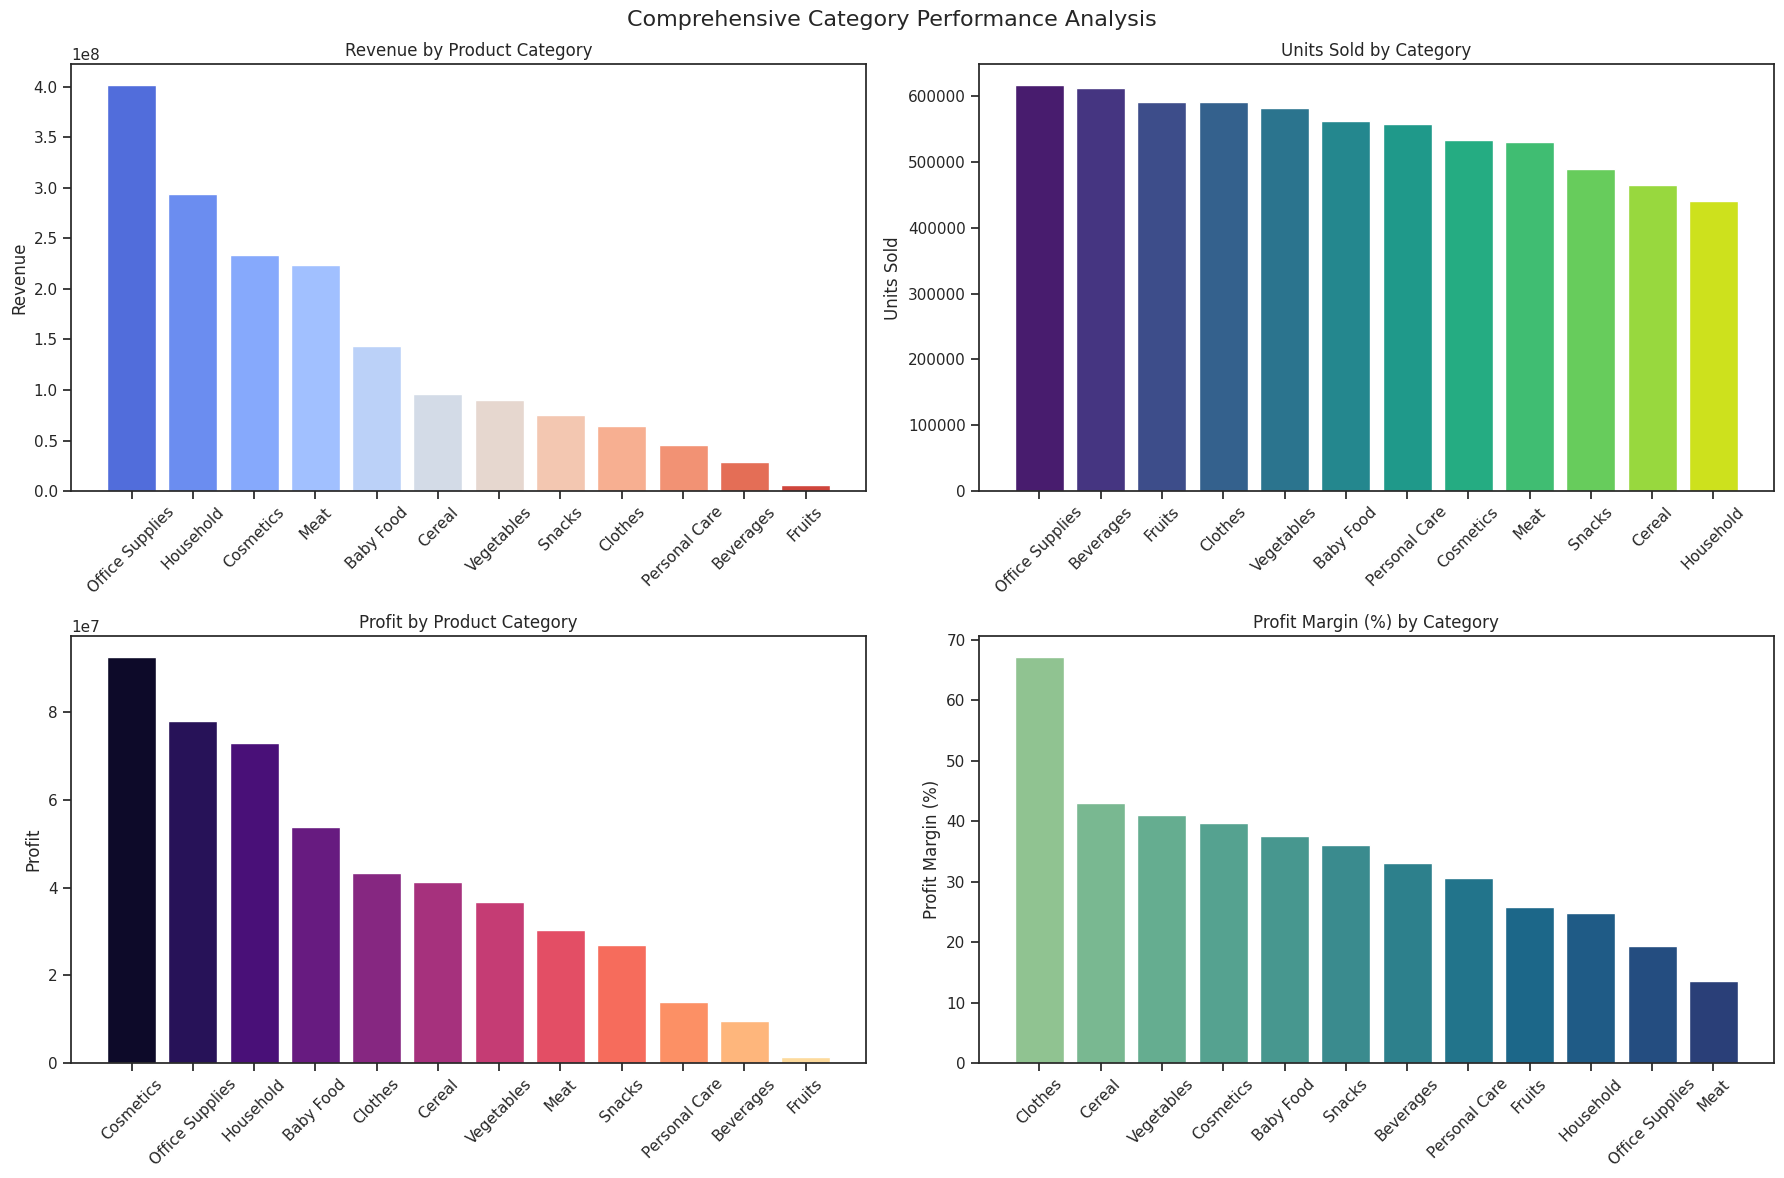

In [ ]:
# Sort by revenue
category_analysis_sorted_by_revenue = category_analysis.sort_values(
    "revenue",
    ascending=False
)

# Sort by units_sold
category_analysis_sorted_by_units_sold = category_analysis.sort_values(
    "units_sold",
    ascending=False
)

# Sort by profit
category_analysis_sorted_by_profit = category_analysis.sort_values(
    "profit",
    ascending=False
)

# Calculate and sort by margin
category_analysis["margin"] = (
    category_analysis["profit"] / category_analysis["revenue"]
)

category_analysis_sorted_by_margin = category_analysis.sort_values(
    "margin",
    ascending=False
)

# Create color palettes
colors_rev = sns.color_palette("coolwarm", len(category_analysis))
colors_units = sns.color_palette("viridis", len(category_analysis))
colors_profit = sns.color_palette("magma", len(category_analysis))
colors_margin = sns.color_palette("crest", len(category_analysis))

# Create 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(18,12))

# --- Revenue ---
axes[0, 0].bar(
    category_analysis_sorted_by_revenue.index,
    category_analysis_sorted_by_revenue["revenue"],
    color=colors_rev
)
axes[0, 0].set_title("Revenue by Product Category")
axes[0, 0].set_ylabel("Revenue")
axes[0, 0].tick_params(axis='x', rotation=45)

# --- Units Sold ---
axes[0, 1].bar(
    category_analysis_sorted_by_units_sold.index,
    category_analysis_sorted_by_units_sold["units_sold"],
    color=colors_units
)
axes[0, 1].set_title("Units Sold by Category")
axes[0, 1].set_ylabel("Units Sold")
axes[0, 1].tick_params(axis='x', rotation=45)

# --- Profit ---
axes[1, 0].bar(
    category_analysis_sorted_by_profit.index,
    category_analysis_sorted_by_profit["profit"],
    color=colors_profit
)
axes[1, 0].set_title("Profit by Product Category")
axes[1, 0].set_ylabel("Profit")
axes[1, 0].tick_params(axis='x', rotation=45)

# --- Profit Margin ---
axes[1, 1].bar(
    category_analysis_sorted_by_margin.index,
    category_analysis_sorted_by_margin["margin"] * 100,
    color=colors_margin
)
axes[1, 1].set_title("Profit Margin (%) by Category")
axes[1, 1].set_ylabel("Profit Margin (%)")
axes[1, 1].tick_params(axis='x', rotation=45)

plt.suptitle("Comprehensive Category Performance Analysis", fontsize=16)
plt.tight_layout()
plt.show()

**Лідерують категорії -  Cosmetics, Office Supplies, Household**

**Аналіз ефективності товарних категорій – ключові висновки**

Аналіз виручки, обсягів продажів, прибутку та маржинальності показав суттєві відмінності між категоріями за рівнем ефективності та стратегічної важливості.

1.   Основний драйвер виручки – Office Supplies
Ця категорія формує найбільшу частку доходу та є стабільним джерелом прибутку. Вона є фундаментом портфеля компанії.
2.   Найприбутковіша категорія – Cosmetics
Попри те, що за виручкою вона займає третє місце, саме Cosmetics генерує найбільший прибуток. Це свідчить про високу маржу та сильну цінову позицію.
3.   Проблемна зона – Meat
Категорія демонструє високий оборот, але низьку прибутковість. Це може свідчити про високі витрати або низьку маржу.
4.   Високий обсяг – низька цінність
Деякі категорії мають великі обсяги продажів, але невисокий фінансовий внесок. Це сигнал для перегляду цінової або операційної стратегії.


### Аналіз по країнах

In [ ]:
# ===== 1. Aggregation by country =====
delivery_stats = sales_dataset.groupby("country_name").agg({
    "profit": "sum",
    "units_sold": "sum",
    "delivery_days": ["mean", "min", "max"]
})
print(delivery_stats)

                             profit units_sold delivery_days        
                                sum        sum          mean min max
country_name                                                        
Albania                 10490706.02      90608     26.190476   2  49
Andorra                 15410036.63     185686     26.275000   0  50
Armenia                  9422353.18     150665     26.172414   2  50
Austria                 10027509.64     145573     28.500000   3  50
Belarus                 11852421.05     153432     25.250000   1  49
Belgium                  7476060.14     120506     26.538462   1  48
Bosnia and Herzegovina  13257602.77     153545     26.060606   1  50
Bulgaria                10408342.61     150088     26.800000   3  48
Croatia                  7318229.45      73945     18.352941   2  45
Cyprus                  10032220.56     158743     23.233333   1  49
Czech Republic          13635593.78     142446     25.225806   0  50
Denmark                  9617418.0

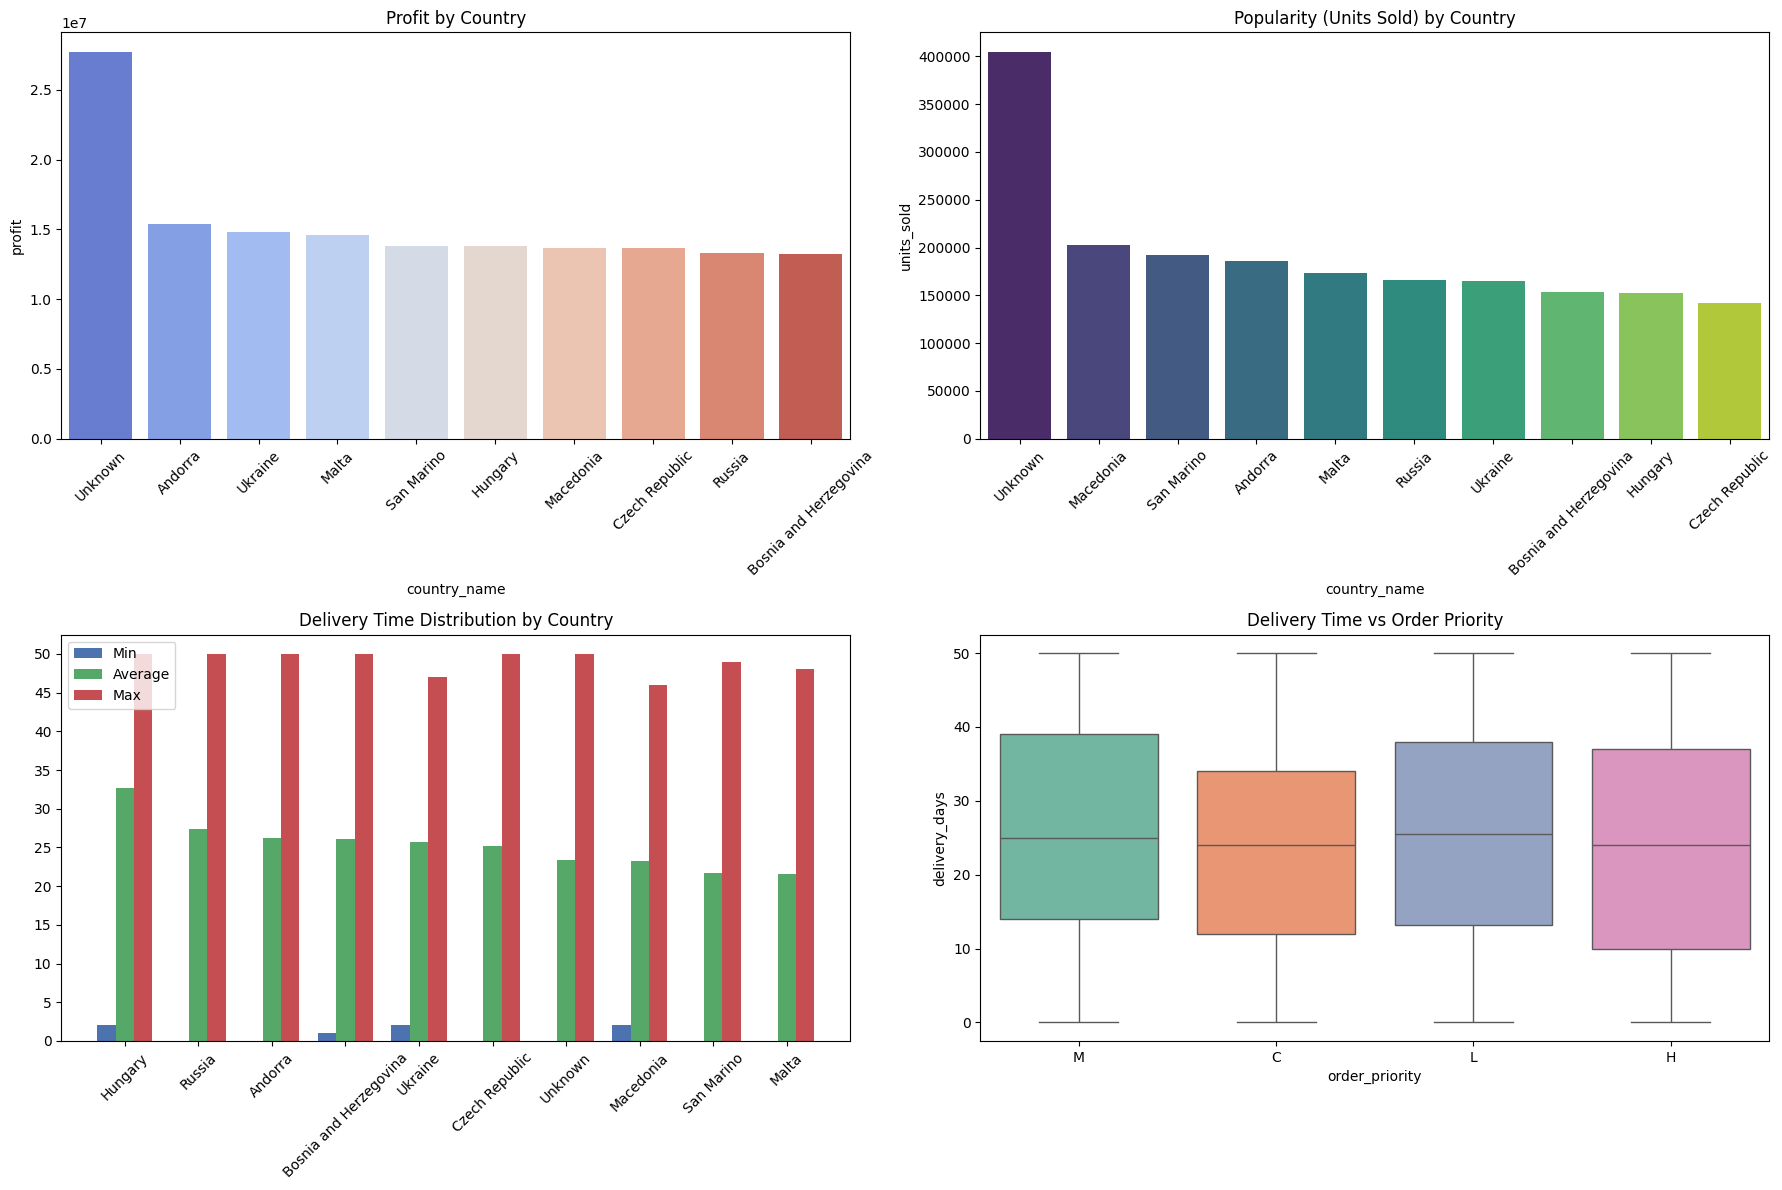

In [ ]:
# Removing multiindex
delivery_stats.columns = ["profit", "units_sold", "delivery_mean", "delivery_min", "delivery_max"]

delivery_stats = delivery_stats.sort_values("profit", ascending=False).head(10)


# ===== 2. Preparing the order for schedules =====
delivery_stats_profit = delivery_stats.sort_values("profit", ascending=False)
delivery_stats_units = delivery_stats.sort_values("units_sold", ascending=False)
delivery_stats_delivery = delivery_stats.sort_values("delivery_mean", ascending=False)


# ===== 3. Dashboard 2x2 =====
fig, axes = plt.subplots(2, 2, figsize=(18,12))

# ---------------- Profit ----------------
sns.barplot(
    x=delivery_stats_profit.index,
    y=delivery_stats_profit["profit"],
    hue=delivery_stats_profit.index,
    palette="coolwarm",
    legend=False,
    ax=axes[0,0]
)

axes[0,0].set_title("Profit by Country")
axes[0,0].tick_params(axis='x', rotation=45)


# ---------------- Units Sold ----------------
sns.barplot(
    x=delivery_stats_units.index,
    y=delivery_stats_units["units_sold"],
    hue=delivery_stats_units.index,
    palette="viridis",
    legend=False,
    ax=axes[0,1]
)

axes[0,1].set_title("Popularity (Units Sold) by Country")
axes[0,1].tick_params(axis='x', rotation=45)


# ---------------- Delivery Time (Min / Mean / Max) ----------------
x = np.arange(len(delivery_stats_delivery))
width = 0.25

axes[1,0].bar(
    x - width,
    delivery_stats_delivery["delivery_min"],
    width,
    label="Min",
    color="#4C72B0"
)

axes[1,0].bar(
    x,
    delivery_stats_delivery["delivery_mean"],
    width,
    label="Average",
    color="#55A868"
)

axes[1,0].bar(
    x + width,
    delivery_stats_delivery["delivery_max"],
    width,
    label="Max",
    color="#C44E52"
)

axes[1,0].set_xticks(x)
axes[1,0].set_xticklabels(
    delivery_stats_delivery.index,
    rotation=45
)
axes[1,0].set_yticks(
    np.arange(
        0,
        sales_dataset["delivery_days"].max()+1,
        5
    )
)
axes[1,0].set_title("Delivery Time Distribution by Country")
axes[1,0].legend()


# ---------------- Order Priority vs Delivery ----------------
sns.boxplot(
    data=sales_dataset,
    x="order_priority",
    y="delivery_days",
    hue="order_priority",
    palette="Set2",
    legend=False,
    ax=axes[1,1]
)

axes[1,1].set_title("Delivery Time vs Order Priority")


plt.tight_layout()
plt.show()

Аналіз аномалії "Unknown" та її вплив

Оскільки категорія Unknown займає лідуючі позиції за прибутком (**27.7 млн**) та обсягом продажів (**404,853 одиниць**), ми висуваємо наступні гіпотези:

Географічна розмитість: Це не одна країна, а сукупність замовлень з різних регіонів, де дані про місцезнаходження не були зафіксовані.

Логістична стабільність: Попри відсутність назви країни, середній час доставки для цих замовлень становить **23.4 дні**, що є середнім показником по компанії. Це означає, що система логістики працює стабільно навіть за відсутності повних адресних даних у звітності.

Бізнес-рекомендації щодо "Unknown":Впровадження обов'язкових полів: Рекомендується зробити поле "Країна" обов'язковим при оформленні замовлення (як для Online, так і для Offline каналів).Або спробувати відновити дані через поштові індекси або IP-адреси, щоб зрозуміти, які реальні ринки приносять ці 27 мільйонів usd.

Якщо ми приберемо "Unknown", щоб побачити реальну конкуренцію між країнами, картина наступна:

Лідери:

За прибутком (usd)      Андорра (**15.4M usd**), Україна (**14.8M usd**), Мальта(**14.6M usd**)

За обсягом (Units)     Македонія (**203k**), Сан-Марино (**192k**), Андорра (**186k**)

 Ключовий інсайт: Угорщина має один з найвищих показників прибутку (**13.7млн**), але при цьому найгіршу швидкість доставки (**понад 32 дні**).Висновок: Угорський ринок є надзвичайно лояльним або дефіцитним. Клієнти готові чекати товар понад місяць. Це сигналізує про величезний потенціал: якщо оптимізувати доставку до середніх **23 днів**, продажі можуть зрости ще більше.

Графік Delivery Time vs Order Priority дає відповідь на важливе бізнес-питання: чи швидше ми доставляємо пріоритетні замовлення?

Критичний інсайт: Медіанний час доставки для всіх рівнів пріоритету (H, L, C, M) знаходиться приблизно на одному рівні — 25 днів.

Бізнес-висновок: Система пріоритезації замовлень (Order Priority) наразі не працює ефективно з точки зору швидкості відвантаження. Замовлення з пріоритетом "High" (H) доставляються так само довго, як і з пріоритетом "Medium" (M). Це зона росту для сервісу.

In [ ]:
sales_dataset["subregion"].nunique()

6

### Аналіз по регіонам

In [ ]:
region_analysis = sales_dataset.groupby("region").agg({
    "delivery_days": "mean",
    "order_id": "nunique"
})

print(region_analysis)

         delivery_days  order_id
region                          
Asia         26.085366        82
Europe       24.790378      1164
Unknown      23.439024        82


In [ ]:
sales_dataset['region'].unique()

array(['Europe', 'Unknown', 'Asia'], dtype=object)

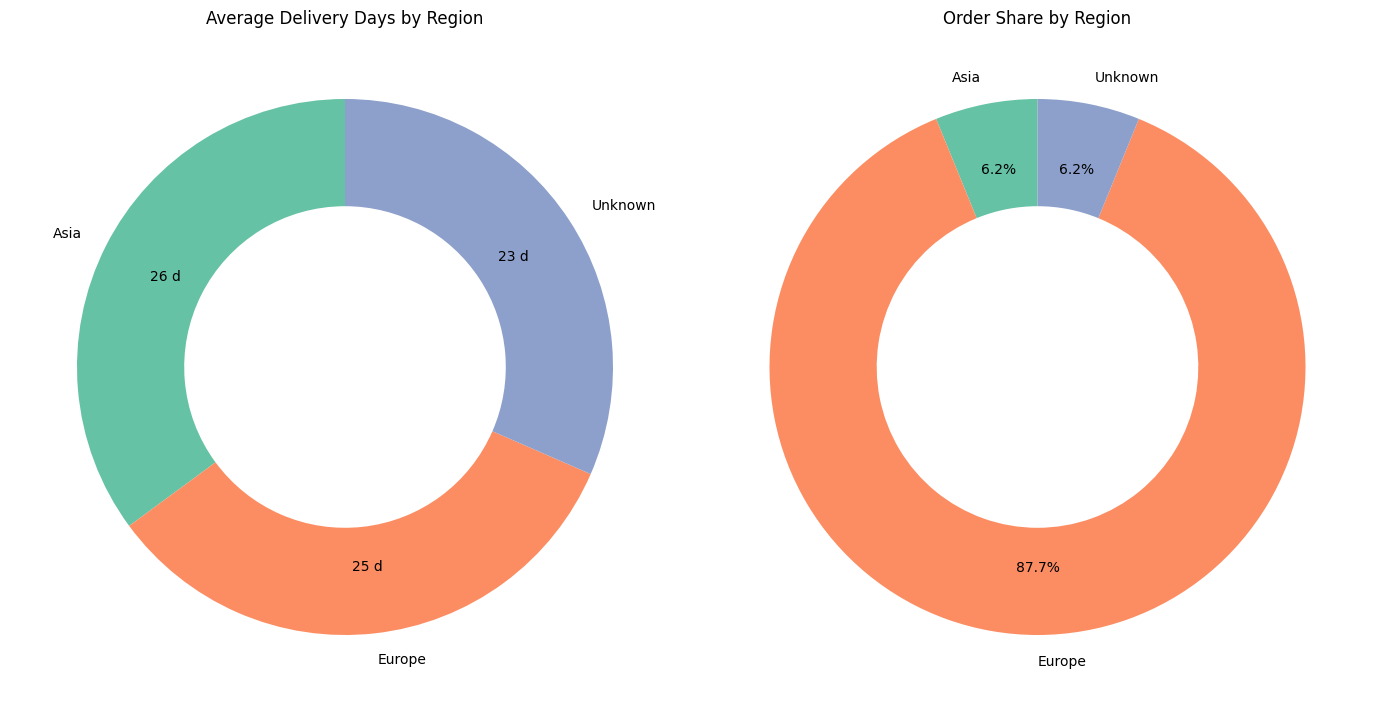

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,7))

colors = sns.color_palette("Set2", len(region_analysis))

# --------- Donut 1: Average Delivery Days ---------
def format_days(pct, allvals):
    absolute = round(pct/100. * sum(allvals))
    return f"{absolute} d"

wedges1, texts1, autotexts1 = axes[0].pie(
    region_analysis["delivery_days"],
    labels=region_analysis.index,
    autopct=lambda pct: format_days(pct, region_analysis["delivery_days"]),
    startangle=90,
    colors=colors,
    wedgeprops=dict(width=0.4),
    pctdistance=0.75,
    textprops={'fontsize':10}
)

axes[0].set_title("Average Delivery Days by Region")


# --------- Donut 2: Order Share (%) ---------
axes[1].pie(
    region_analysis["order_id"],
    labels=region_analysis.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    wedgeprops=dict(width=0.4),
    pctdistance=0.75,
    textprops={'fontsize':10}
)

axes[1].set_title("Order Share by Region")

plt.tight_layout()
plt.show()

Враховуючи, що Європа займає майже 88% ринку, варто розглянути маркетингові кампанії для Азії, щоб зменшити залежність від одного регіону.

Швидкість відвантаження у 23-26 днів — це досить тривалий період для сучасного ритейлу. Рекомендується проаналізувати етапи обробки замовлення, щоб скоротити цей інтервал хоча б до 14-18 днів, що значно підвищить лояльність клієнтів.

### Аналіз по каналам

In [ ]:
channel_analysis = sales_dataset.groupby("sales_channel").agg({
    "profit": "sum",
    "units_sold": "sum"
})

print(channel_analysis)

                     profit  units_sold
sales_channel                          
offline        2.534665e+08     3320363
online         2.479679e+08     3256161


In [ ]:
sales_dataset["sales_channel"].unique()

array(['online', 'offline'], dtype=object)

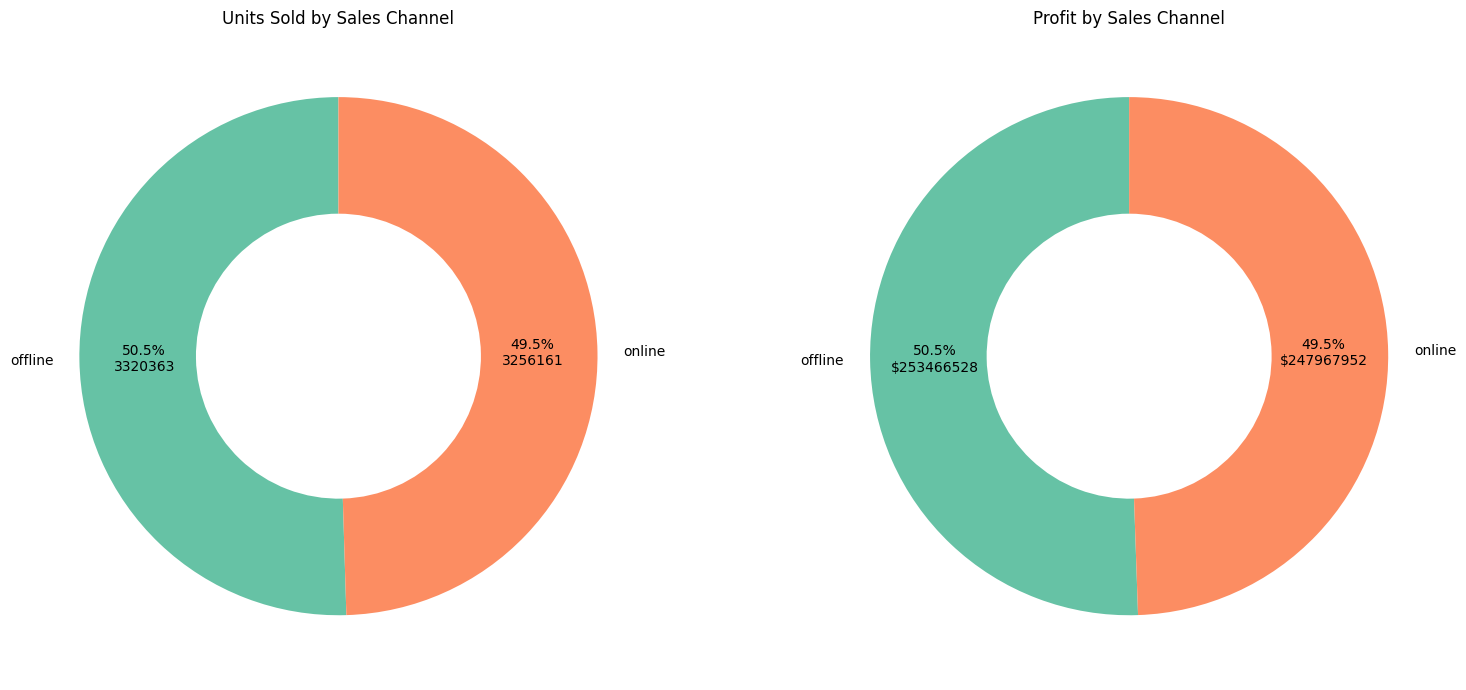

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16,7))

colors = sns.color_palette("Set2", len(channel_analysis))


# =====================================================
# Function for beautiful captions ( % + number )
# =====================================================

def format_labels(pct, values, is_money=False):
    absolute = pct / 100 * sum(values)

    if is_money:
        return f"{pct:.1f}%\n${int(absolute)}"
    else:
        return f"{pct:.1f}%\n{int(absolute)}"


# =====================================================
# Donut 1 — Units Sold
# =====================================================

axes[0].pie(
    channel_analysis["units_sold"],
    labels=channel_analysis.index,
    autopct=lambda pct: format_labels(
        pct,
        channel_analysis["units_sold"]
    ),
    startangle=90,
    colors=colors,
    wedgeprops=dict(width=0.45),
    pctdistance=0.75
)

axes[0].set_title("Units Sold by Sales Channel")


# =====================================================
# Donut 2 — Profit
# =====================================================

axes[1].pie(
    channel_analysis["profit"],
    labels=channel_analysis.index,
    autopct=lambda pct: format_labels(
        pct,
        channel_analysis["profit"],
        is_money=True
    ),
    startangle=90,
    colors=colors,
    wedgeprops=dict(width=0.45),
    pctdistance=0.75
)

axes[1].set_title("Profit by Sales Channel")

plt.tight_layout()
plt.show()

Дані демонструють мінімальний розрив між каналами.
Така модель робить бізнес надзвичайно стійким. Наприклад, під час локдаунів онлайн-канал здатний повністю підтримати обсяги, а при проблемах з інтернетом чи логістикою "останньої милі" — виручить офлайн.

Також можемо прослідкувати що напевно в Offline каналах і забувають вказувати країну і ця система не налагоджена. Варто передивитись та змінити цей важливий для аналізу і вцілому компанії момент.

In [ ]:
# Analyze delivery performance and profitability by product category
cat_delivery = sales_dataset.groupby("product_category").agg({
    "delivery_days": ["mean", "min", "max"],
    "profit": "sum"
})

# Flatten multi-level column names for easier interpretation
cat_delivery.columns = ["del_mean", "del_min", "del_max", "profit"]

# Sort categories by average delivery time (slowest delivery first)
cat_delivery = cat_delivery.sort_values("del_mean", ascending=False)

print(cat_delivery)

                   del_mean  del_min  del_max       profit
product_category                                          
Cereal            27.184466        0       50  41255034.15
Office Supplies   26.707317        1       50  77977176.25
Baby Food         26.339286        0       50  53940997.16
Cosmetics         25.912281        0       50  92723306.17
Meat              25.909091        0       50  30337736.00
Snacks            25.543689        0       49  27027422.40
Fruits            24.419643        1       50   1425929.52
Beverages         24.123967        0       50   9601662.78
Household         23.938144        0       50  72962466.77
Vegetables        23.491228        0       50  36776002.72
Clothes           23.104762        0       50  43431314.40
Personal Care     20.763158        0       50  13975410.68


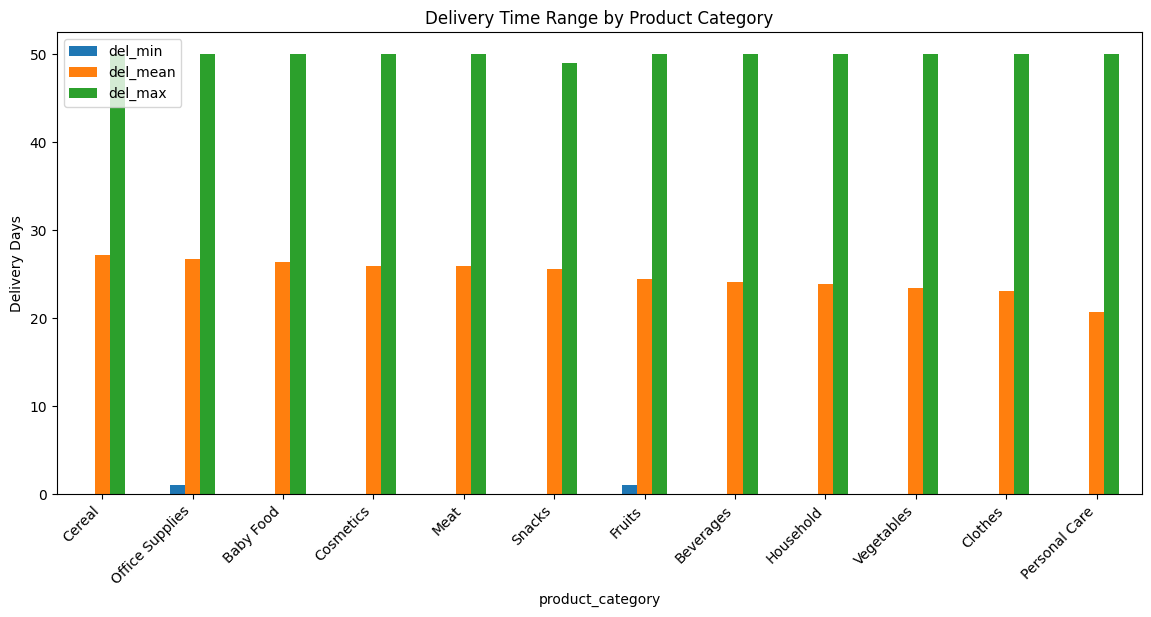

In [ ]:
cat_delivery[["del_min","del_mean","del_max"]].plot(
    kind="bar",
    figsize=(14,6)
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Delivery Days")
plt.title("Delivery Time Range by Product Category")
plt.show()

Для швидкопсувних товарів (якщо Fruits або Beverages мають такий статус) середній термін у 24-25 днів може бути критичним. Варто перевірити, чи не впливає такий довгий термін відвантаження на відсоток повернень у цих категоріях.

Найшвидші категорії: Найменший середній час відвантаження мають категорії Personal Care (пр.21 день) та Clothes (пр.23 дні). Це "швидкі" товари, які, ймовірно, мають вищий оборот на складах.
Також бачимо що більше 50 днів немає доставки, швидше за все є певний регламент на відвантаження.

### Чи впливає Delivery Time на Profit

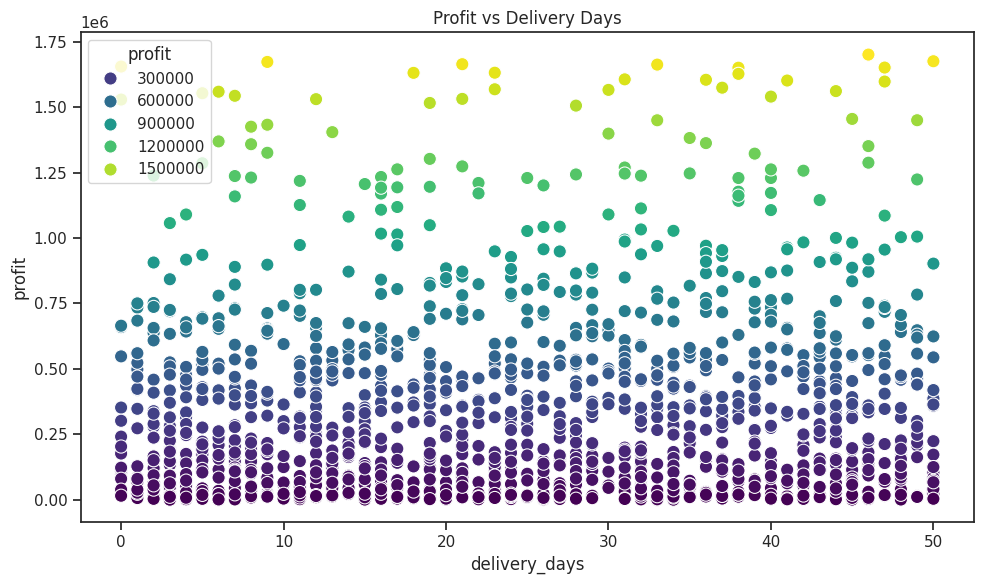

In [ ]:
sns.set_theme(style="ticks")

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=sales_dataset,
    x="delivery_days",
    y="profit",
    hue="profit",
    palette="viridis",
    s=90
)

plt.title("Profit vs Delivery Days")
plt.tight_layout()
plt.show()

Аналіз scatter plot показує слабку або відсутню кореляцію між часом доставки та прибутком. Дані демонструють широкий розкид значень прибутку при будь-якому значенні delivery_days, що може свідчити про вплив інших бізнес-факторів на profit.

###  Динаміка продажів (у часі) у розрізі категорій товарів, країн, регіонів. Основні тенденції

In [ ]:
sales_dataset.columns

Index(['order_id', 'order_date', 'ship_date', 'delivery_days',
       'delivery_category', 'order_priority', 'sales_channel', 'country_name',
       'region', 'subregion', 'product_category', 'units_sold', 'unit_price',
       'unit_cost', 'revenue', 'total_cost', 'profit'],
      dtype='object')

In [ ]:
dynamics_of_sales_by_category = sales_dataset.groupby(["product_category", "order_date"])["units_sold"].sum()
print(dynamics_of_sales_by_category.head())


product_category  order_date
Baby Food         2010-01-01    9367
                  2010-01-11    6238
                  2010-01-18     649
                  2010-02-10    4983
                  2010-03-16    6833
Name: units_sold, dtype: int64


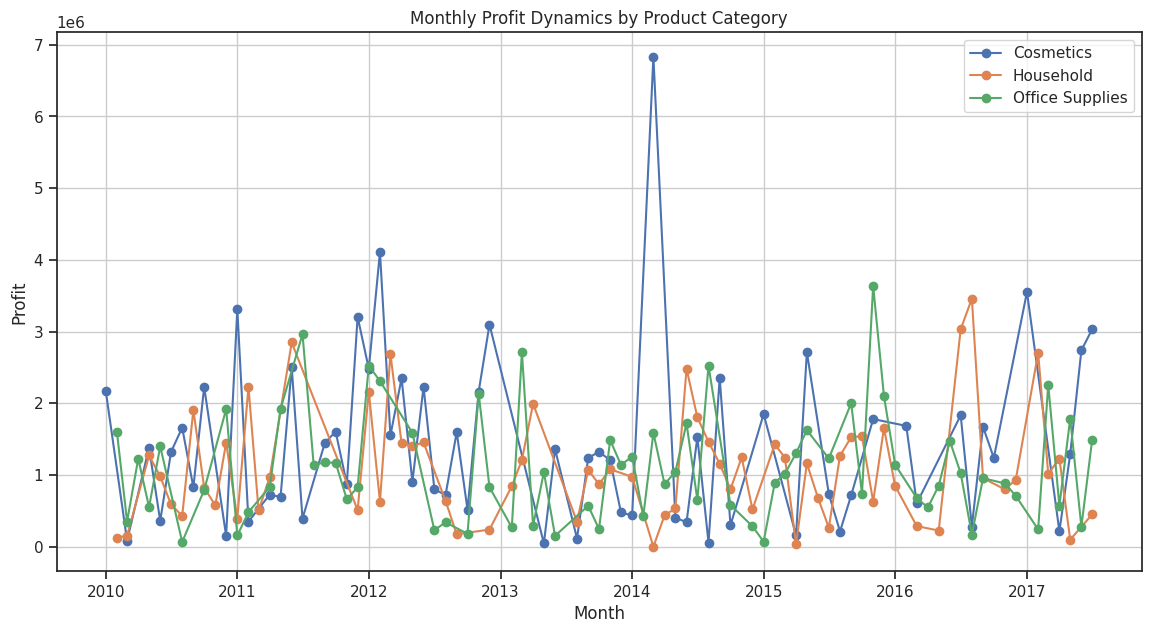

In [ ]:
# Convert order date to monthly period for trend analysis
sales_dataset["month"] = sales_dataset["order_date"].dt.to_period("M")

# Identify top 3 product categories by total profit
top_categories = (
    sales_dataset.groupby("product_category")["profit"]
    .sum()
    .sort_values(ascending=False)
    .head(3)
    .index
)

# Aggregate monthly profit by product category
monthly_profit = (
    sales_dataset
    .groupby(["product_category", "month"])["profit"]
    .sum()
    .reset_index()
)

# Filter only top-performing categories
monthly_profit = monthly_profit[
    monthly_profit["product_category"].isin(top_categories)
]

# Visualize monthly profit dynamics
plt.figure(figsize=(14,7))

for category in monthly_profit["product_category"].unique():
    product_data = monthly_profit[
        monthly_profit["product_category"] == category
    ].sort_values("month")

    plt.plot(product_data["month"].dt.to_timestamp(),
             product_data["profit"],
             marker="o",
             label=category)

plt.xlabel("Month")
plt.ylabel("Profit")
plt.title("Monthly Profit Dynamics by Product Category")
plt.legend()
plt.grid(True)
plt.show()

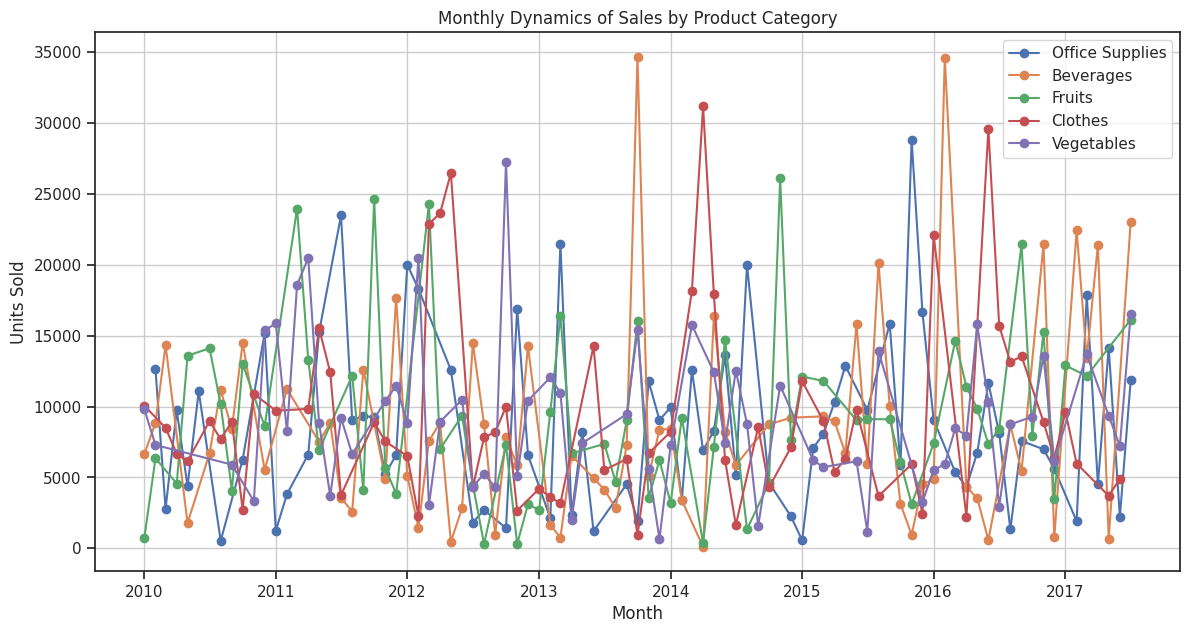

In [ ]:
# Convert a date to a monthly period
sales_dataset["month"] = sales_dataset["order_date"].dt.to_period("M")

# Top 5 categories by sales
top_categories = (
    sales_dataset.groupby("product_category")["units_sold"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

plt.figure(figsize=(14,7))

for category in top_categories:
    subset = (
        sales_dataset[sales_dataset["product_category"] == category]
        .groupby("month")["units_sold"]
        .sum()
        .sort_index()
    )

    # Convert back to datetime to display the graph correctly
    plt.plot(
        subset.index.to_timestamp(),
        subset.values,
        marker="o",
        label=category
    )

plt.title("Monthly Dynamics of Sales by Product Category")
plt.xlabel("Month")
plt.ylabel("Units Sold")
plt.legend()
plt.grid()
plt.show()

Косметика (Cosmetics): Це абсолютний "зірковий" продукт за прибутком. Аномальний пік на початку 2014 року — прибуток сягнув майже $7 млн за місяць, хоча кількість проданих одиниць у цей період не була рекордною.

Інсайт: Це свідчить про реалізацію дуже дорогої партії товару або зміну цінової політики в цьому кварталі.

Офісне приладдя (Office Supplies): Показує стабільну динаміку, але з набагато нижчою маржинальністю порівняно з косметикою.

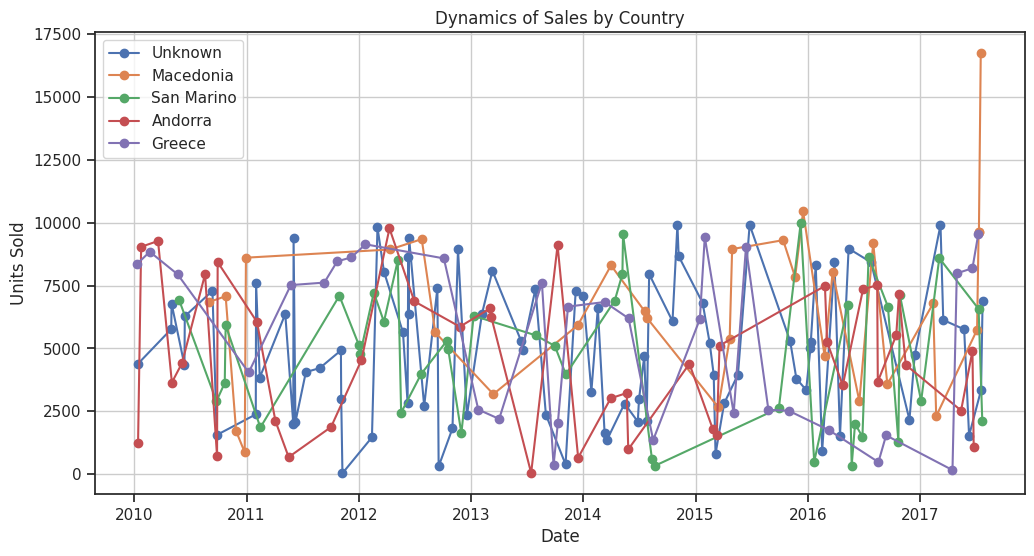

In [ ]:
# Identify top 5 countries by total sales volume
top_countries = (
    sales_dataset.groupby("country_name")["units_sold"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

# Visualize sales volume time series for leading countries
plt.figure(figsize=(12,6))

for country in top_countries:
   # Aggregate daily sales volume per country
    subset = (
        sales_dataset[sales_dataset["country_name"] == country]
        .groupby("order_date")["units_sold"]
        .sum()
        .sort_index()
    )
    # Plot sales trend over time
    plt.plot(
          subset.index,
          subset.values,
          marker="o",
          label=country
      )
plt.title("Dynamics of Sales by Country")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.legend()
plt.grid()
plt.show()


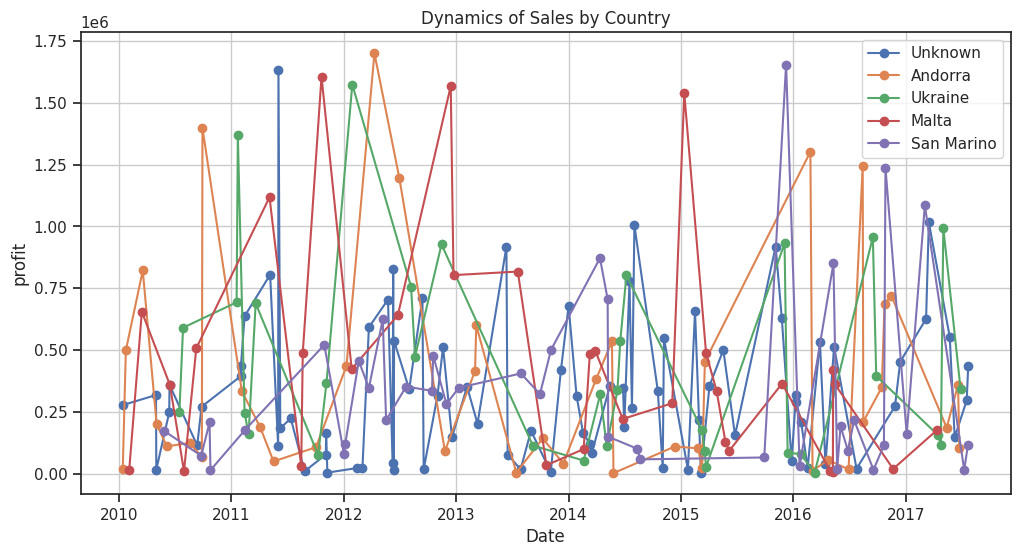

In [ ]:
# Identify top 5 countries by total profit
top_countries = (
    sales_dataset.groupby("country_name")["profit"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

# Visualize profit time series for top-performing countries
plt.figure(figsize=(12,6))

for country in top_countries:
    # Aggregate daily profit per selected country
    subset = (
        sales_dataset[sales_dataset["country_name"] == country]
        .groupby("order_date")["profit"]
        .sum()
        .sort_index()
    )
    # Plot profit trend over time
    plt.plot(
          subset.index,
          subset.values,
          marker="o",
          label=country
      )
plt.title("Dynamics of Sales by Country")
plt.xlabel("Date")
plt.ylabel("profit")
plt.legend()
plt.grid()
plt.show()

Македонія показала аномальний сплеск продажів у середині 2017 року (понад $15,000$ одиниць за короткий період), що вивело її в топ за кількістю.
Всі топ 4 країн за динамікою, мають дуже високу волатильність (різкі стрибки вгору і вниз). Це може свідчити про те, що продажі в цих країнах залежать від великих разових контрактів або сезонних акцій, планових закупівель.
Та знову Unknow яка не дає гідно оцінити нашу динаміку.

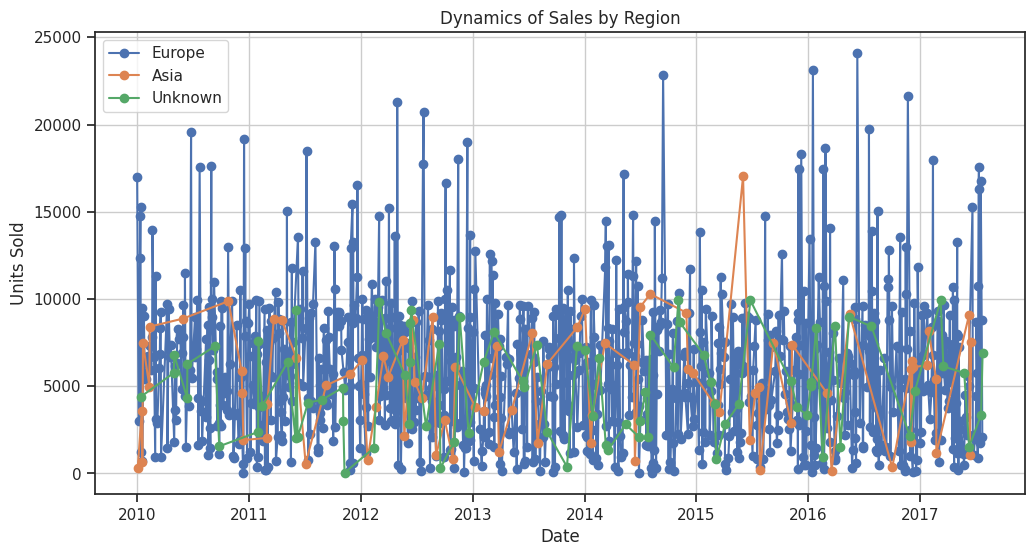

In [ ]:
# Identify top 5 regions by total sales volume (units sold)
top_countries = (
    sales_dataset.groupby("region")["units_sold"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

# Plot sales dynamics over time for top regions
plt.figure(figsize=(12,6))

for country in top_countries:
  # Aggregate daily sales volume per region
    subset = (
        sales_dataset[sales_dataset["region"] == country]
        .groupby("order_date")["units_sold"]
        .sum()
        .sort_index()
    )
    # Plot sales trend over time
    plt.plot(
          subset.index,
          subset.values,
          marker="o",
          label=country
      )
plt.title("Dynamics of Sales by Region")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.legend()
plt.grid()
plt.show()

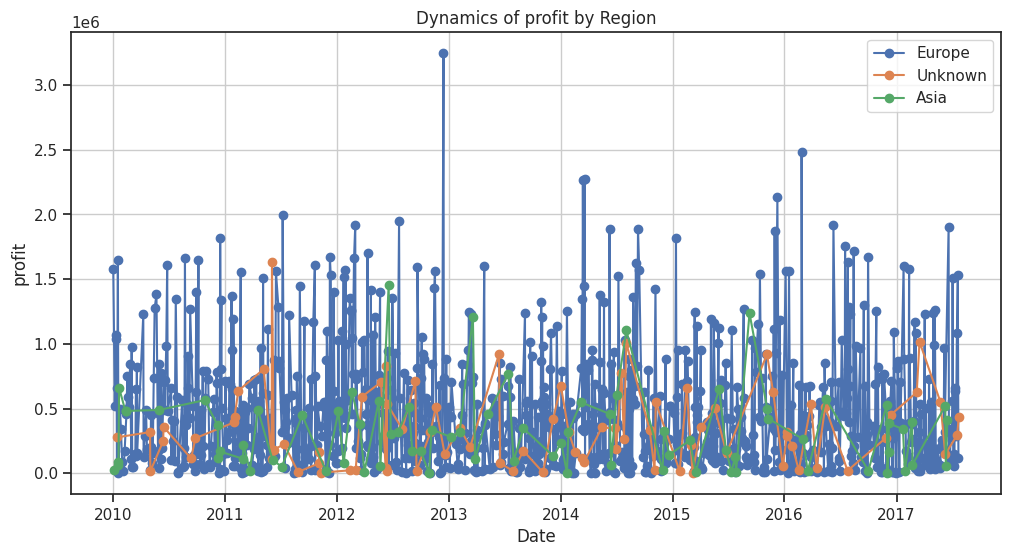

In [ ]:
# Identify top 5 regions by total profit
top_countries = (
    sales_dataset.groupby("region")["profit"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

# Plot profit time series for the top-performing regions
plt.figure(figsize=(12,6))

for country in top_countries:
    # Aggregate daily profit per selected region
    subset = (
        sales_dataset[sales_dataset["region"] == country]
        .groupby("order_date")["profit"]
        .sum()
        .sort_index()
    )
    # Plot profit trend over time
    plt.plot(
          subset.index,
          subset.values,
          marker="o",
          label=country
      )
plt.title("Dynamics of profit by Region")
plt.xlabel("Date")
plt.ylabel("profit")
plt.legend()
plt.grid()
plt.show()

Європа не лише найбільший ринок, а й найбільш волатильний (мінливий). Ми бачимо регулярні різкі сплески прибутку, що може бути пов'язано з великими квартальними закупками B2B-клієнтів. Азія не має пікових показників в доході, крім невеликого піку у 2011 році десь влітку.

### Аналіз продажів по днях тижня

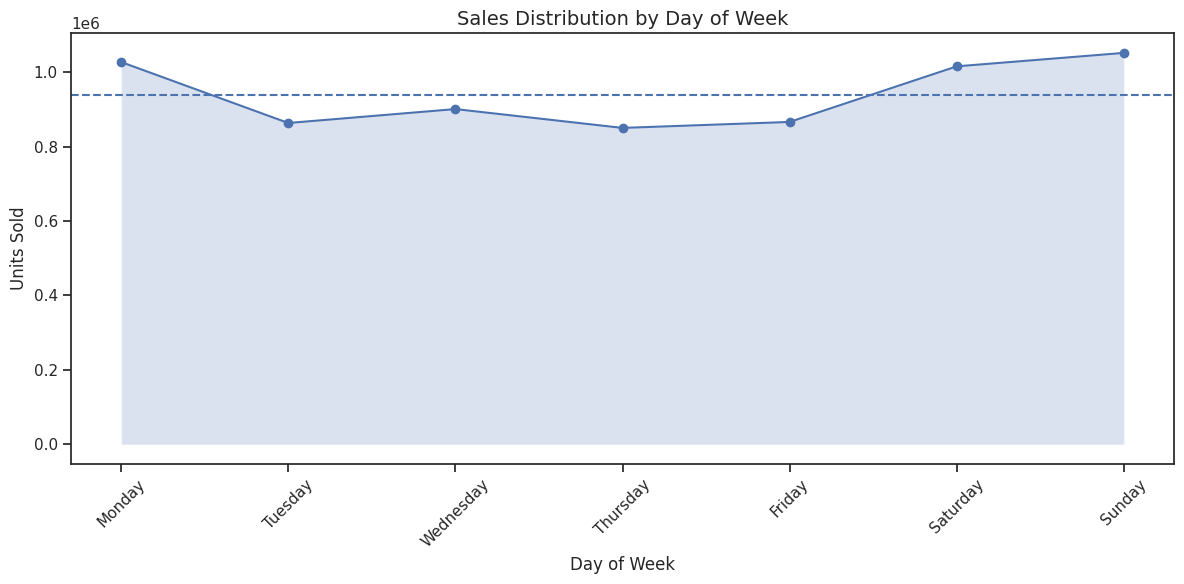

In [ ]:
# Extract day of week from order date for weekly sales analysis
sales_dataset["day_of_week"] = sales_dataset["order_date"].dt.day_name()

# Define correct weekday order to ensure proper chronological visualization
days_order = ["Monday", "Tuesday", "Wednesday",
              "Thursday", "Friday", "Saturday", "Sunday"]

# Convert day_of_week to ordered categorical type for consistent grouping and plotting
sales_dataset["day_of_week"] = pd.Categorical(
    sales_dataset["day_of_week"],
    categories=days_order,
    ordered=True
)

# Aggregate total units sold by day of week
weekday_sales = (
    sales_dataset
    .groupby("day_of_week", observed=True)["units_sold"]
    .sum()
    .reindex(days_order)
)

colors = [
    "#4C72B0" if day not in ["Saturday", "Sunday"]
    else "#DD8452"
    for day in weekday_sales.index
]

# Create a modern line chart to visualize weekly sales distribution
plt.figure(figsize=(12,6))

plt.plot(
    weekday_sales.index,
    weekday_sales.values,
    marker="o"
)

# Highlight area under the curve to improve visual perception of volume
plt.fill_between(
    weekday_sales.index,
    weekday_sales.values,
    alpha=0.2
)

# Add horizontal line representing average weekly sales
plt.axhline(weekday_sales.mean(), linestyle='--')

plt.title("Sales Distribution by Day of Week", fontsize=14)
plt.xlabel("Day of Week")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipython-input-3803196029.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sales_dataset.groupby(["product_category", "day_of_week"])["units_sold"]


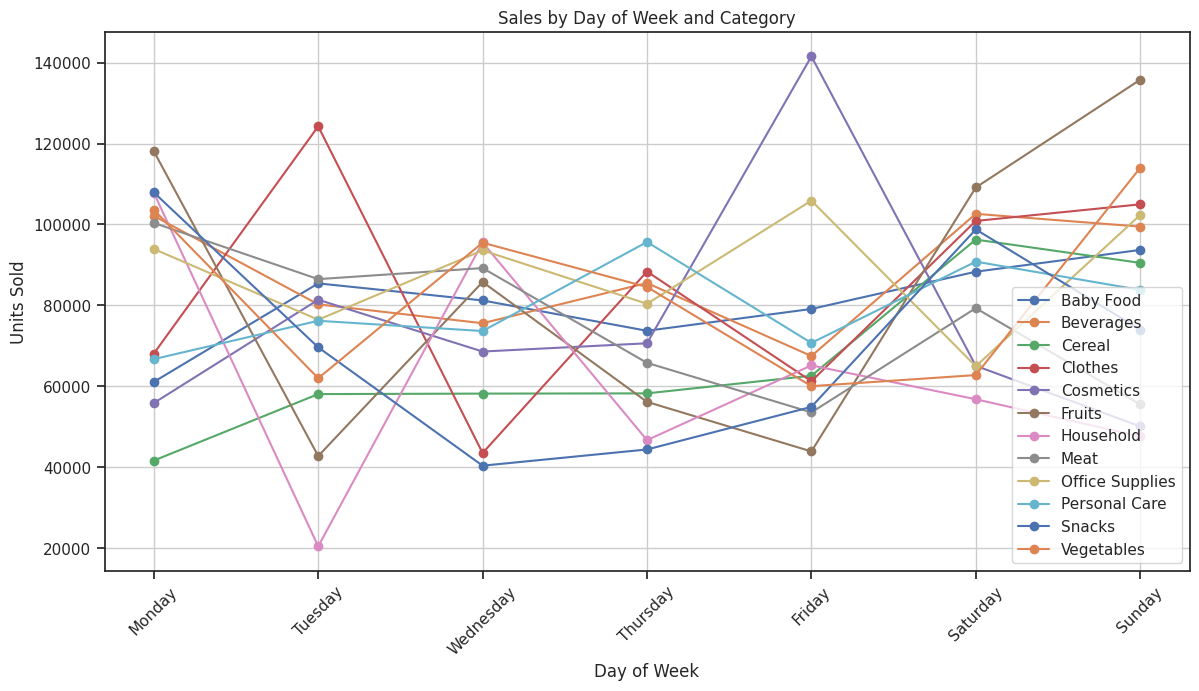

In [ ]:
# Aggregate total units sold by product category and day of week
weekday_category = (
    sales_dataset.groupby(["product_category", "day_of_week"])["units_sold"]
    .sum()
    .reset_index()
)
# Create a line chart to visualize weekly sales patterns across categories
plt.figure(figsize=(14,7))

for category in weekday_category["product_category"].unique():

  # Filter data for a specific category and sort by day of week
    data = weekday_category[
        weekday_category["product_category"] == category
    ].sort_values("day_of_week")

    # Plot weekly sales trend for each category
    plt.plot(data["day_of_week"], data["units_sold"], marker="o", label=category)

plt.title("Sales by Day of Week and Category")
plt.xlabel("Day of Week")
plt.ylabel("Units Sold")
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [ ]:
# Calculate weekly seasonality metrics for each product category
seasonality_check = (
    sales_dataset.groupby(["product_category", "day_of_week"])["units_sold"]
    .sum()
    .groupby(level=0)
    .agg(["mean", "std"])
)
# Compute coefficient of variation (CV) to measure demand variability
seasonality_check["cv"] = seasonality_check["std"] / seasonality_check["mean"]
# Sort categories by variability (highest seasonality first)
seasonality_check.sort_values("cv", ascending=False)

/tmp/ipython-input-4138624503.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sales_dataset.groupby(["product_category", "day_of_week"])["units_sold"]


,mean,std,cv
product_category,,,
Household,62892.714286,30060.172109,0.477960
Fruits,84524.571429,37751.599506,0.446635
Cosmetics,76184.428571,30548.181151,0.400977
Snacks,70022.857143,25947.021380,0.370551
Clothes,84483.571429,28188.914209,0.333661
Cereal,66526.428571,19583.490248,0.294372
Vegetables,83220.571429,22057.568201,0.265049
Meat,75768.571429,17868.859643,0.235835
Office Supplies,88234.428571,14792.614935,0.167651


Загальне:
Пікові дні: Найбільша кількість проданих товарів спостерігається у неділю (понад 1 млн одиниць) та понеділок.

Спад активності: Середина тижня (вівторок–п’ятниця) демонструє нижчі показники продажів, які знаходяться нижче середньої лінії.

Бізнес-інсайт: Вихідні дні є критично важливими для обсягів продажів. Це ідеальний час для запуску маркетингових розсилок або акцій "вихідного дня".

Окремо по категоріях:
Household - Різкий провал у вівторок, значні коливання, можлива акційна або імпульсна категорія
Fruits - Сильні піки на вихідних (Перед вихідними)
Cosmetics  - Пік у п'ятницю (Перед вихідними / подіями)

Snacks Підвищення у п'ятницю–неділю
Clothes - Сильний пік у вівторок, та підвищена активність з суботи на неділю (можлива акційна у вівторок)

Аналіз продажів по днях тижня показав, що категорії Household, Fruits та Cosmetics демонструють високу внутрішньотижневу сезонність (CV > 0.4), що свідчить про залежність попиту від дня тижня.
Натомість Baby Food, Personal Care та Beverages мають стабільний попит без виражених коливань (CV < 0.2).

Категорії з сезонністю:
Можна запускати таргетовані акції перед піковими днями
Оптимізувати запаси під вихідні

# Висновок

Проведений аналіз діяльності компанії за період 2010–2017 рр. дозволяє сформувати цілісну картину бізнес-моделі та визначити точки росту.

Ключові результати:
Бізнес-профіль: Компанія орієнтована на масштабні операції (B2B/Опт) із високою маржинальністю (29%) та середнім чеком $1.28M. Це свідчить про стійку позицію у преміальному або промисловому сегменті.

Продуктовий портфель: Визначено чітку роль категорій: Office Supplies як фундамент стабільності та Cosmetics як головний драйвер чистого прибутку. Водночас логістичний цикл у 25 днів та відсутність реальної пріоритезації доставки («Critical» доставляється так само, як і «Low») є основними операційними викликами.

Географія: Попри домінування Європи (88% ринку), бізнес має значний прихований потенціал у неідентифікованих регіонах (Unknown генерує понад $27.7M прибутку). Угорщина виділяється як ринок із найвищою лояльністю, попри логістичні затримки (понад 32 дні).

Поведінка: Виявлено чітку внутрішньотижневу сезонність для категорій Household, Fruits та Cosmetics, з піком активності у вихідні та понеділок, що дозволяє оптимізувати маркетингові витрати.

Перспективи глибшого аналізу:
Варто розуміти, що цей аналіз дає загальну стратегічну картину, проте це лише "верхівка айсберга". При глибшому зануренні та більших досліджень, порівнянь за різними критеріями, можна знайти ще безліч інсайтів.